In [1]:
import gzip as gz
import os
import tqdm
import sys

sys.path.append('./../utils')

import pandas as pd
import numpy as np
import scipy
import statsmodels
import statsmodels.api as sm
import scanpy as sc
import anndata as ad

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

import sc_utils

from statsmodels.stats.multitest import fdrcorrection

/home/trc891/.conda/envs/cfn_final/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/trc891/.conda/envs/cfn_final/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/home/trc891/.conda/envs/cfn_final/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/home/trc891/.conda/envs/cfn_final/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/home/trc891/.conda/envs/cfn_final/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Impor

In [2]:
DATA_DIR = '../data/cfhv_sc'
OUT_DIR = '../data/figs/cfhv_sc'

SAMPLE_SHEET_PATH = f'{DATA_DIR}/cfhv_sc_samplesheet.csv'
sample_sheet = pd.read_csv(SAMPLE_SHEET_PATH)

In [3]:
ds_sub = sc.read_h5ad(f'{DATA_DIR}/cfhv_sc_obj.h5ad')

In [4]:
ds_sub.uns

{'Class_colors': array(['#1f77b4', '#ff7f0e'], dtype=object),
 'Library ID_colors': array(['#1f77b4', '#ff7f0e', '#279e68', '#d62728', '#aa40fc', '#8c564b',
        '#e377c2', '#b5bd61', '#17becf', '#aec7e8', '#ffbb78', '#98df8a',
        '#ff9896', '#c5b0d5', '#c49c94', '#f7b6d2', '#dbdb8d'],
       dtype=object),
 'Sex_colors': array(['#1f77b4', '#ff7f0e'], dtype=object),
 '_scvi_manager_uuid': '43769f8f-2d30-4178-a250-52a495c6b840',
 '_scvi_uuid': 'ed8741e2-ac05-4950-aa78-3e8d620101f6',
 'cell_type_annot_colors': array(['#1f77b4', '#ff7f0e', '#279e68', '#d62728', '#aa40fc', '#8c564b',
        '#e377c2', '#b5bd61', '#17becf', '#aec7e8', '#ffbb78', '#98df8a',
        '#ff9896', '#c5b0d5', '#c49c94'], dtype=object),
 'hvg': {'flavor': 'seurat_v3'},
 'leiden': {'params': {'n_iterations': -1,
   'random_state': 0,
   'resolution': 0.4}},
 'leiden_colors': array(['#1f77b4', '#ff7f0e', '#279e68', '#d62728', '#aa40fc', '#8c564b',
        '#e377c2', '#b5bd61', '#17becf', '#aec7e8', '#ffbb78'

In [5]:
ds_sub.uns['cell_type_annot_colors']

array(['#1f77b4', '#ff7f0e', '#279e68', '#d62728', '#aa40fc', '#8c564b',
       '#e377c2', '#b5bd61', '#17becf', '#aec7e8', '#ffbb78', '#98df8a',
       '#ff9896', '#c5b0d5', '#c49c94'], dtype=object)

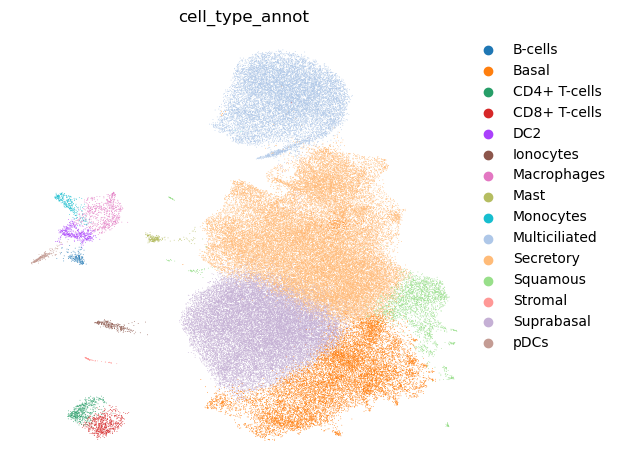

In [6]:
sc.pl.umap(
    ds_sub,
    color=['cell_type_annot'],
    frameon=False,
    show=False
)

plt.legend(ncol=1, loc='upper right', bbox_to_anchor=(1.3, 1), frameon=False)
plt.tight_layout()
plt.savefig('{}/cfhv_fig5a.png'.format(OUT_DIR), dpi=300)

In [7]:
gene_dict = {'Suprabasal': ['KRT10', 'FABP5'],
             'Basal': ['KRT5', 'DLK2'],
             'Secretory': ['SCGB1A1', 'MUC5AC'],
             'Multiciliated': ['FOXJ1', 'PIFO', 'CAPS', 'C20orf85'],
             'Macrophages': ['TYROBP', 'C1QA', 'APOC1'],
             'DC2': ['HLA-DPB1', 'FCER1A', 'CD207'],
             'Monocytes': ['FCN1', 'FCER1G', 'CD14'],
             'pDCs': ['GZMB', 'JCHAIN', 'IL3RA'],
             'B-cells': ['MS4A1', 'CD79A'],
             'CD8+ T-cells': ['CD8A', 'CCL5', 'IL32'],
             'CD4+ T-cells': ['CD4', 'IL7R'],
             'Ionocytes': ['CFTR', 'FOXI1', 'STAP1'],
             'Mast': ['TPSAB1', 'TPSB2', 'MS4A2'],
             'Stromal': ['COL1A1', 'MMP2'],
             'Secretory': ['SCGB1A1', 'MUC5AC', 'BPIFB1', 'BPIFA1'],
             'Squamous': ['SPRR3', 'KRT2', 'KRT6A'],
            }

/home/trc891/.local/lib/python3.10/site-packages/scanpy/tools/_utils.py:41: UserWarning: You’re trying to run this on 1000 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  warnings.warn(
/tmp/ipykernel_1799411/3117684574.py:6: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


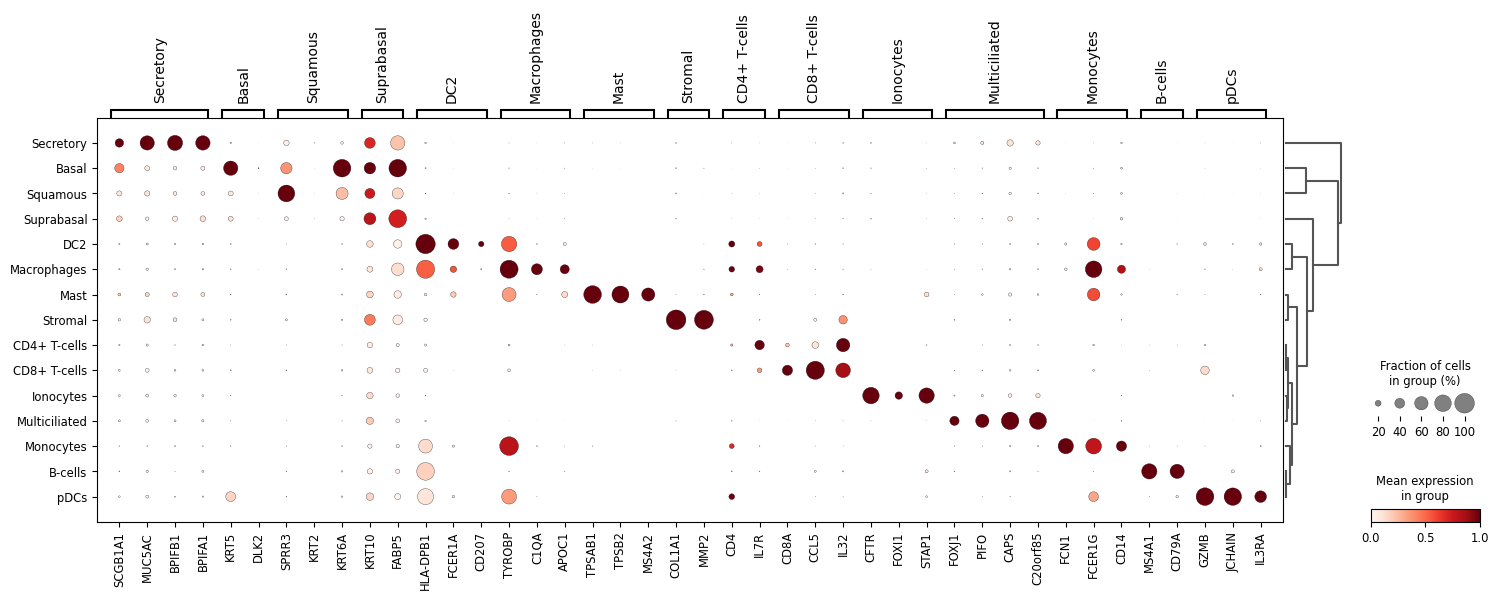

In [8]:
sc.pl.dotplot(ds_sub, gene_dict, groupby='cell_type_annot',
              dendrogram=True, swap_axes=False, standard_scale='var',
              show=False
             )

plt.tight_layout()
plt.savefig('{}/cfhv_sc_fig5b.png'.format(OUT_DIR), dpi=300)
plt.savefig('{}/cfhv_sc_fig5b.svg'.format(OUT_DIR))

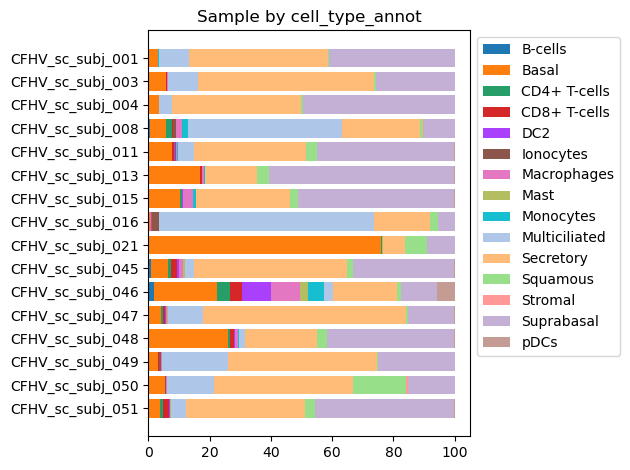

In [9]:
ax = sc_utils.plot_composition(
    ds_sub,
    group_by='Sample',
    color='cell_type_annot',
    relative=True,
    palette=mpl.colors.ListedColormap(ds_sub.uns['cell_type_annot_colors']),
    #plot_numbers=True
)
ax.legend(bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/cfhv_sc_fig5c.png', dpi=300)
plt.savefig(f'{OUT_DIR}/cfhv_sc_fig5c.svg')
plt.show()

In [10]:
batch_name = 'Sample'

# get counts for each sample, then pick a random column. Rename the column
ct_ds = ds_sub.obs.groupby(['cell_type_annot', 'Class', batch_name], observed=True).count().Chemistry.reset_index()
ct_ds = ct_ds.rename(columns={'Chemistry': 'n_cells'})

# get total cell counts for each cluster
cluster_ct = ct_ds.groupby('cell_type_annot', observed=True).sum(numeric_only=True)
# get total cell counts for each subject
subj_ct = ct_ds.groupby(batch_name, observed=True).sum(numeric_only=True)

ct_ds['total_subj'] = 0
for i in subj_ct.itertuples(name=None):
    ct_ds.loc[ct_ds[batch_name] == i[0], 'total_subj'] = i[1]
    
ct_ds['cell_proportion_subj'] = ct_ds['n_cells'] / ct_ds['total_subj']

ct_ds

,cell_type_annot,Class,Sample,n_cells,total_subj,cell_proportion_subj
0,B-cells,CF,CFHV_sc_subj_003,2,10493,0.000191
1,B-cells,CF,CFHV_sc_subj_008,19,3233,0.005877
2,B-cells,CF,CFHV_sc_subj_013,1,2316,0.000432
3,B-cells,CF,CFHV_sc_subj_015,1,721,0.001387
4,B-cells,HV,CFHV_sc_subj_045,45,5053,0.008906
...,...,...,...,...,...,...
193,pDCs,HV,CFHV_sc_subj_046,188,3205,0.058658
194,pDCs,HV,CFHV_sc_subj_047,16,12241,0.001307
195,pDCs,HV,CFHV_sc_subj_048,14,6434,0.002176
196,pDCs,HV,CFHV_sc_subj_049,1,8780,0.000114


In [11]:
stat_results_subj = []
for clust in ct_ds['cell_type_annot'].unique():
    try:
        # for each subject, get proportion of cells that are within each cluster
        ctrl = ct_ds['cell_proportion_subj'][(ct_ds['cell_type_annot'] == clust) & (ct_ds['Class'] == 'HV')]
        cf = ct_ds['cell_proportion_subj'][(ct_ds['cell_type_annot'] == clust) & (ct_ds['Class'] == 'CF')]
        pval = scipy.stats.mannwhitneyu(ctrl, cf).pvalue

        stat_results_subj.append(["cell_type_annot", clust, "HV", "CF", ctrl.size, cf.size, pval])
    except ValueError:
        stat_results_subj.append(["cell_type_annot", clust, "HV", "CF", ctrl.size, cf.size, np.nan])

stat_results_subj = pd.DataFrame(stat_results_subj,
                               columns = ['var', 'val', 'group1', 'group2',
                                          'g1_size', 'g2_size', 'pval']
                                    )

no_nan_filter = stat_results_subj['pval'].notnull()
stat_results_subj['pval_adj'] = [np.nan] * len(no_nan_filter)
stat_results_subj.loc[no_nan_filter, 'pval_adj'] = fdrcorrection(stat_results_subj[no_nan_filter].pval, alpha=0.01)[1]

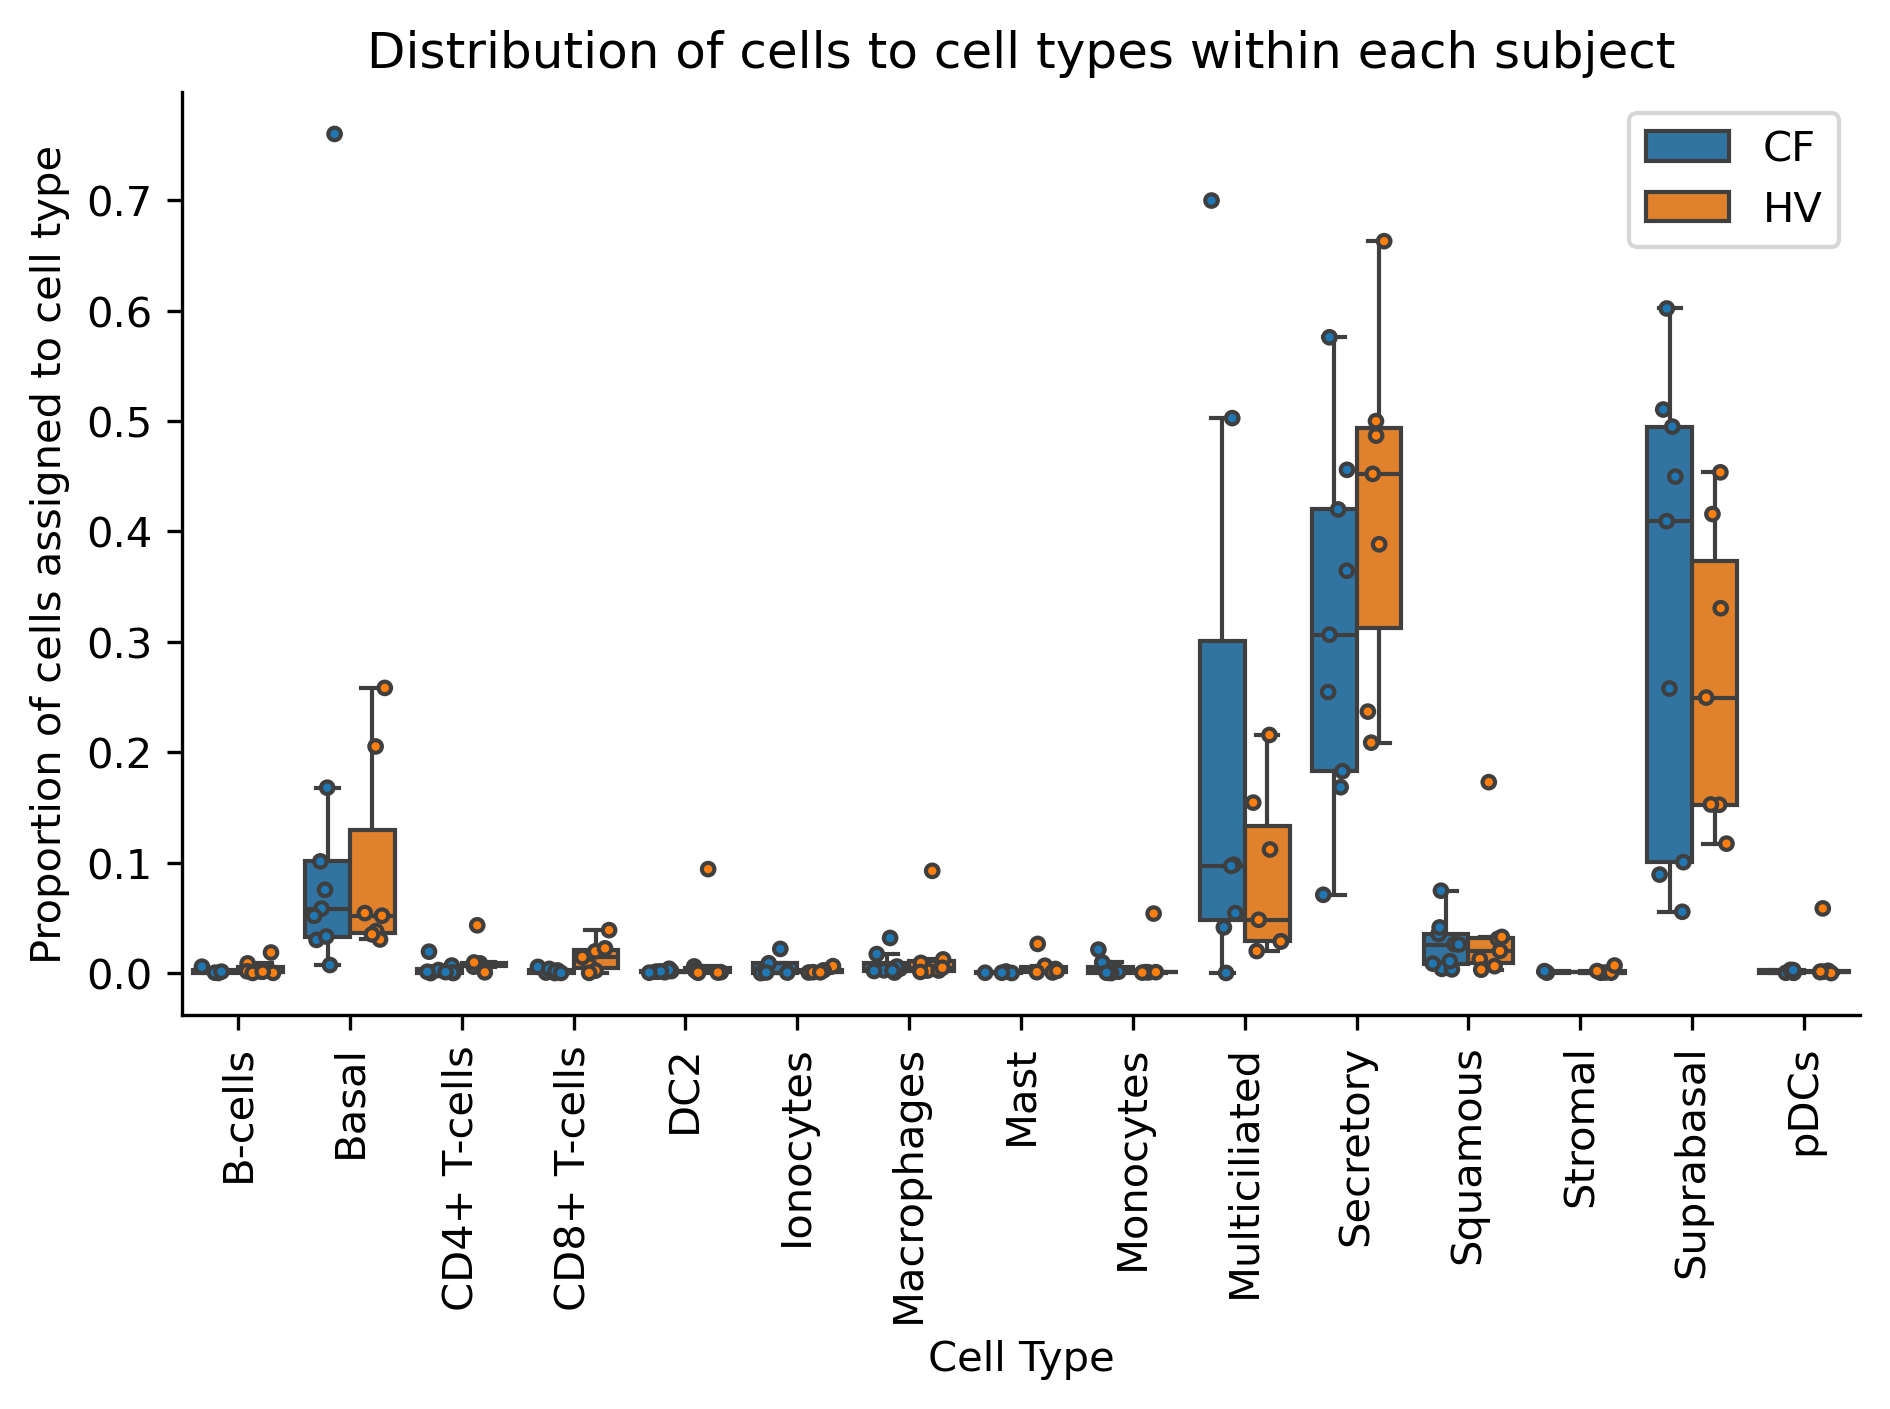

In [12]:
fig, ax = plt.subplots(dpi=300)
#sns.set(style='white')

plt.title('Distribution of cells to cell types within each subject')

sns.boxplot(x='cell_type_annot', y='cell_proportion_subj', data=ct_ds, hue='Class', showfliers=False)
sns.stripplot(x='cell_type_annot', y='cell_proportion_subj', data=ct_ds, hue='Class', size=3, jitter=0.25, dodge=True,
              linewidth=1)

ax.set_ylabel('Proportion of cells assigned to cell type')
plt.xticks(rotation='vertical')
ax.set_xlabel('Cell Type')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

handles, labels = ax.get_legend_handles_labels()
plt.legend(handles[:2], labels[:2])

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/cfhv_sc_fig5d.png', dpi=300)
plt.savefig(f'{OUT_DIR}/cfhv_sc_fig5d.svg')
plt.show()